## Aim: the aim of this notebook is to check the effects of variable grid spacing on the results from DRT fitting
#### Particularly when the resolution of the tau grid exceeds the resolution of the temporal grid


In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import scipy.optimize as so 
import time as tm
import torch
try:
    import pySIMsalabim as sim
except ImportError:
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

### Same grid spacing

In [2]:
# Generate a set of time values and a set of tau values 
time_min = 1e-7
time_max = 1e0
m_time = 800
m_tau = 800

time = np.geomspace(time_min, time_max, m_time)
tau = np.geomspace(time_min, time_max, m_time)

In [3]:
# Create a curve of exponential decays 
U_perf = [1, 4, 2]
tau_perf = [time[19], time[379], time[719]]
offset = 2

y = drt.DRT_curve(time, U_perf, tau_perf, offset=offset)

[]

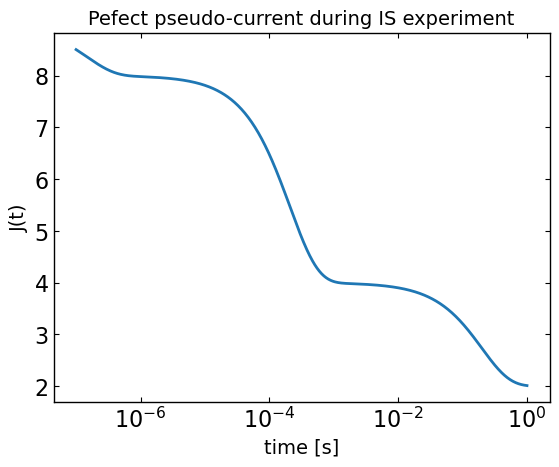

In [4]:
# Plot the curve
plt.plot(time, y, label='Perfect')
plt.title("Pefect pseudo-current during IS experiment")
plt.xlabel("time [s]")
plt.ylabel("J(t)")
plt.xscale('log')
plt.plot()

In [5]:
# Now fit the data for a range of alpha values 
alpha_values = np.geomspace(1e-3, 1e1, 15)
fits = []

for alpha in alpha_values:
    fit = drt.fit_DRT_curve_linear_torch(time, y, tau, alpha=alpha, max_iter=1000)
    fits.append(fit)

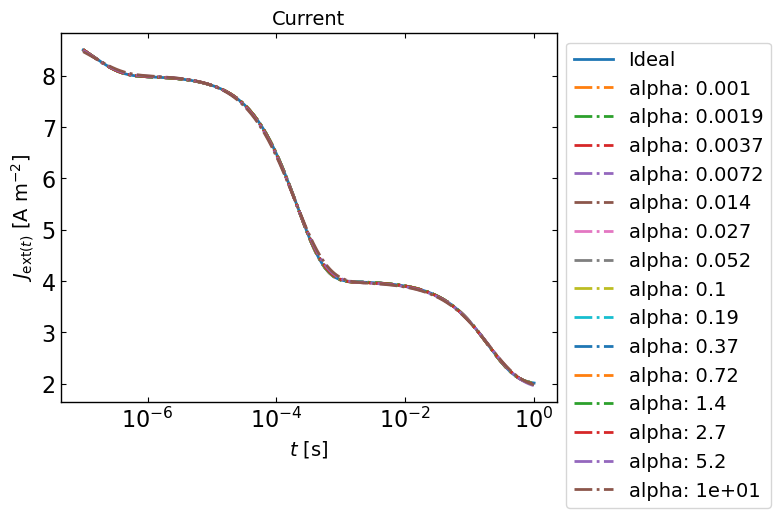

In [6]:
plt.plot(time, y, label='Ideal')

for i in range(len(fits)):
    fit = fits[i]
    plt.plot(time, fit.DRT_curve, label=f'alpha: {alpha_values[i]:.2}', linestyle='-.')

plt.xscale('log')
plt.xlabel("$t$ [$\\text{s}$]")
plt.ylabel("$J_{\\text{ext}(t)}$ [$\\text{A m}^{-2}$]")
plt.xscale('log')
plt.title("Current")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.show()

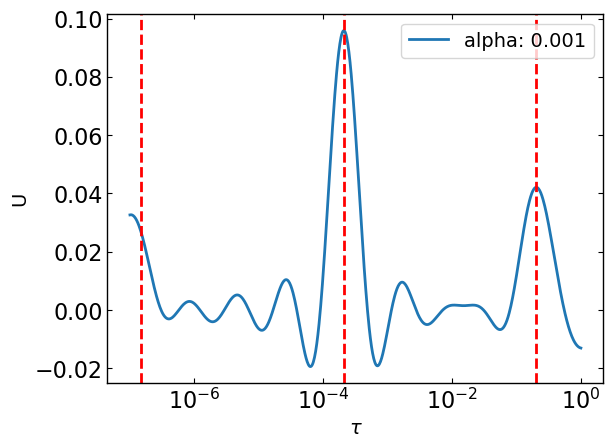

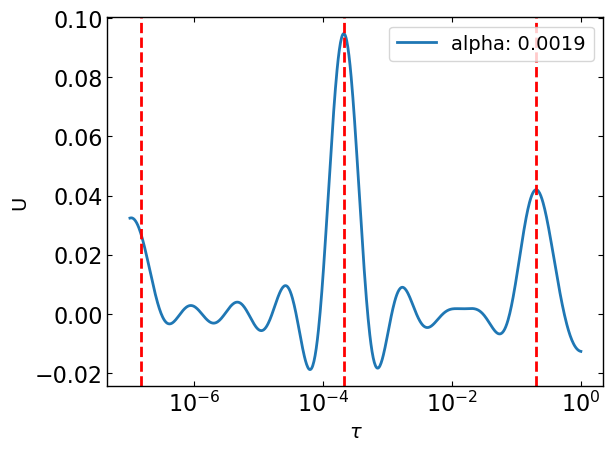

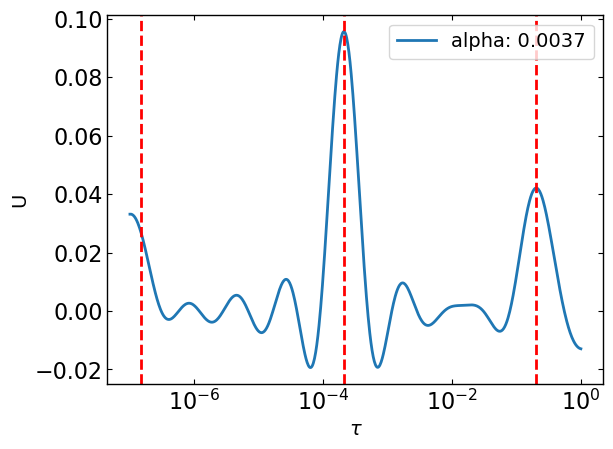

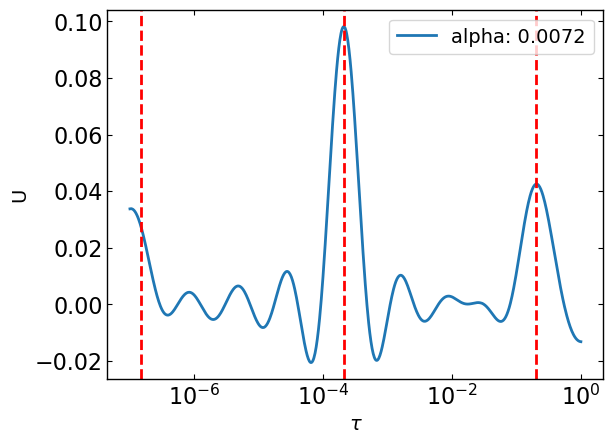

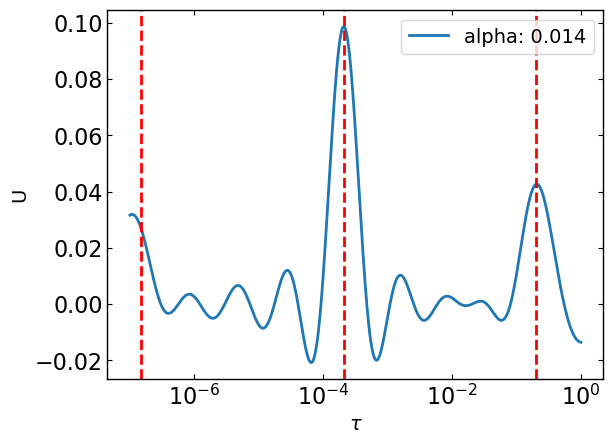

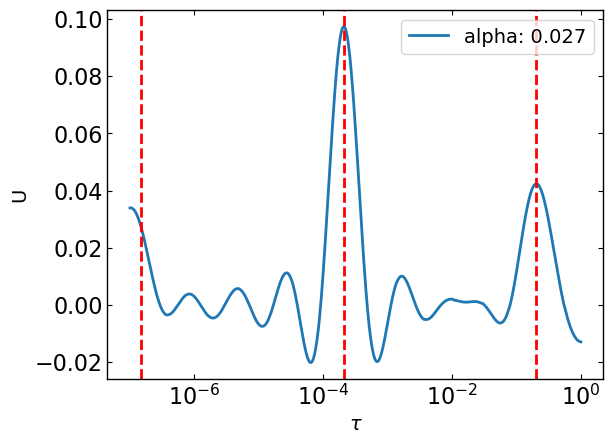

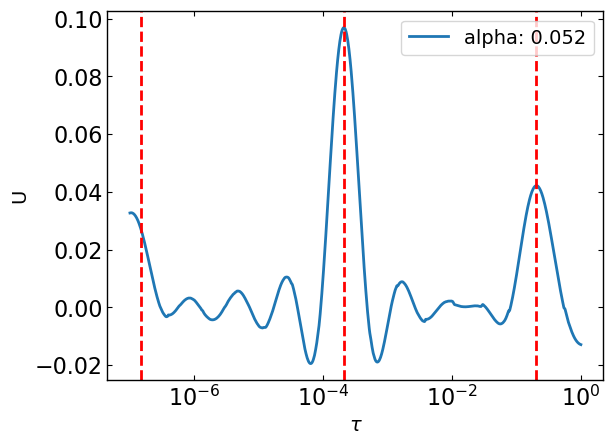

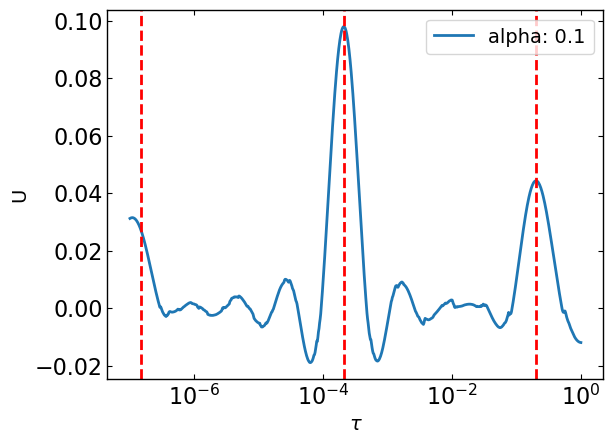

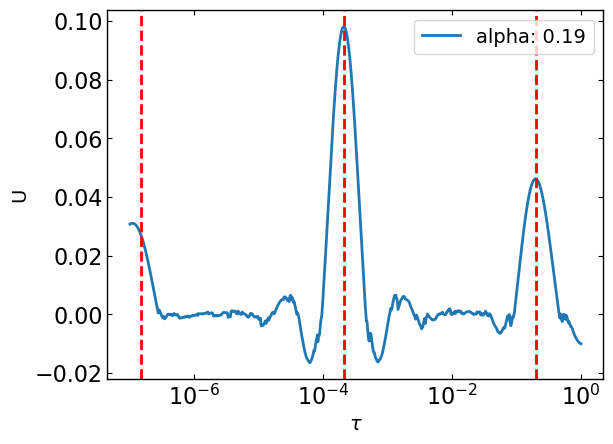

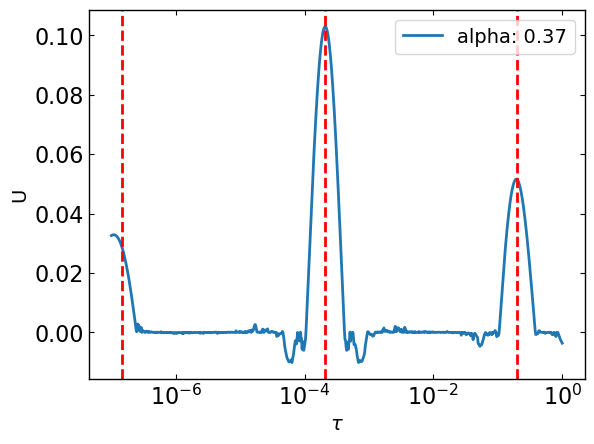

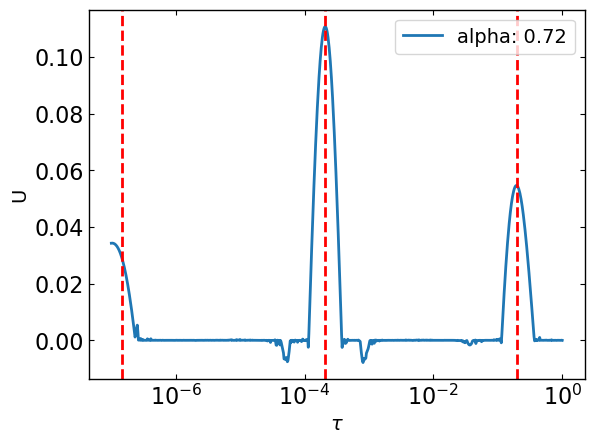

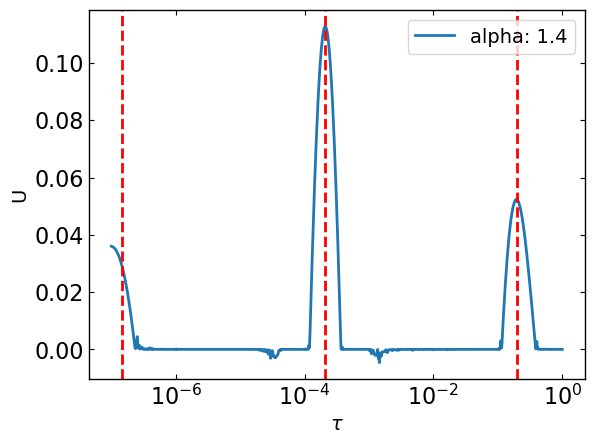

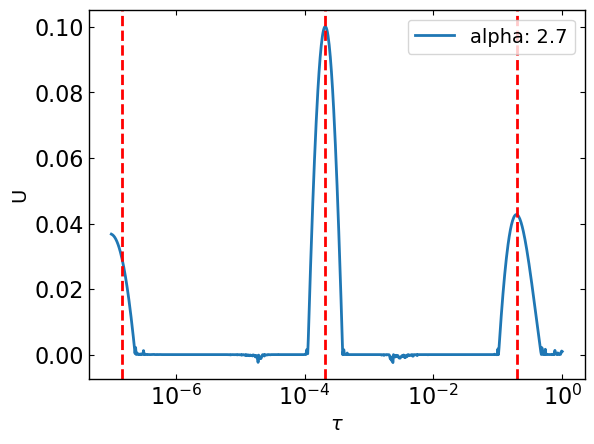

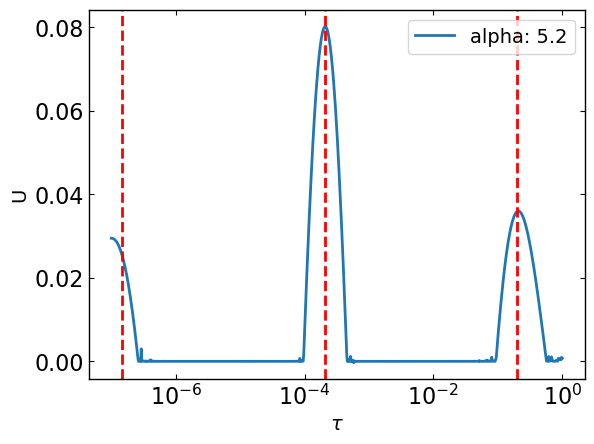

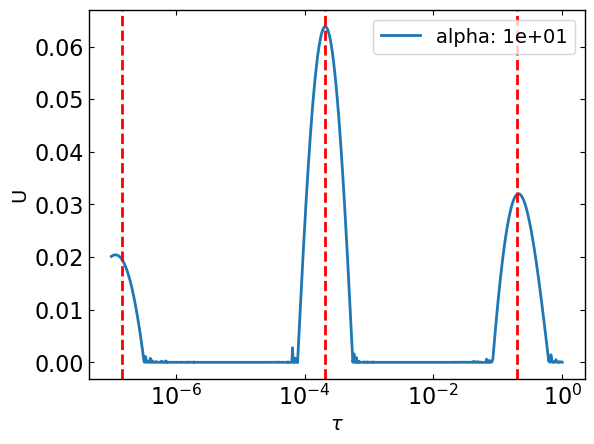

In [7]:
# Plot the resulting DRT curves for each graph
for i in range(len(fits)):
    fit = fits[i]
    plt.plot(fit.tau, fit.U, label=f'alpha: {alpha_values[i]:.2}')
    for tau_value in tau_perf:
        plt.axvline(tau_value, linestyle='--', color='red')
    plt.xlabel("$\\tau$")
    plt.ylabel("U")
    plt.xscale('log')
    plt.legend()
    plt.show()

## Two times the number of tau values to grid spacing

In [8]:
# Generate a set of time values and a set of tau values 
time_min = 1e-7
time_max = 1e0
m_time = 800
m_tau = 1600

time = np.geomspace(time_min, time_max, m_time)
tau = np.geomspace(time_min, time_max, m_tau)

In [9]:
# Now fit the data for a range of alpha values 
alpha_values = np.geomspace(1e-3, 1e1, 15)
fits = []

for alpha in alpha_values:
    fit = drt.fit_DRT_curve_linear_torch(time, y, tau, alpha=alpha, max_iter=1000)
    fits.append(fit)

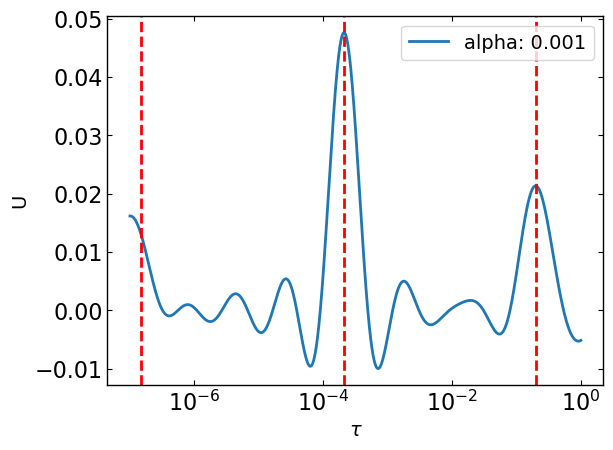

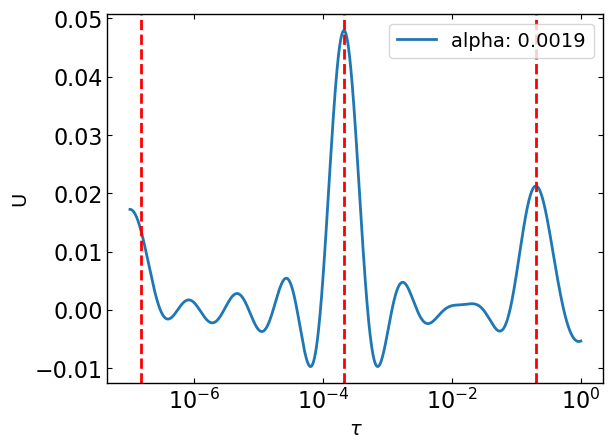

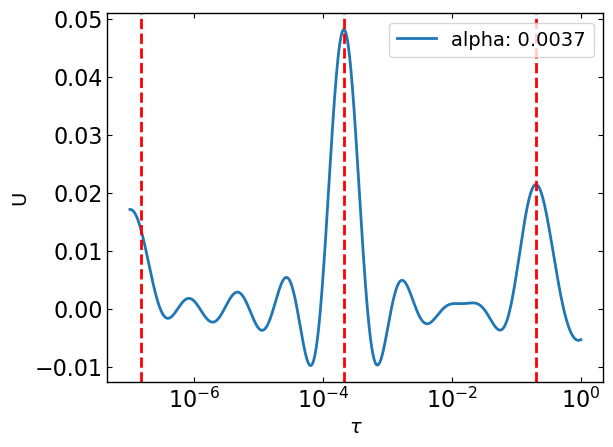

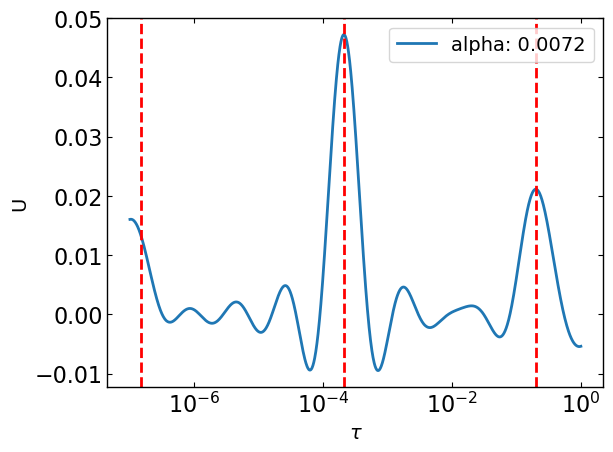

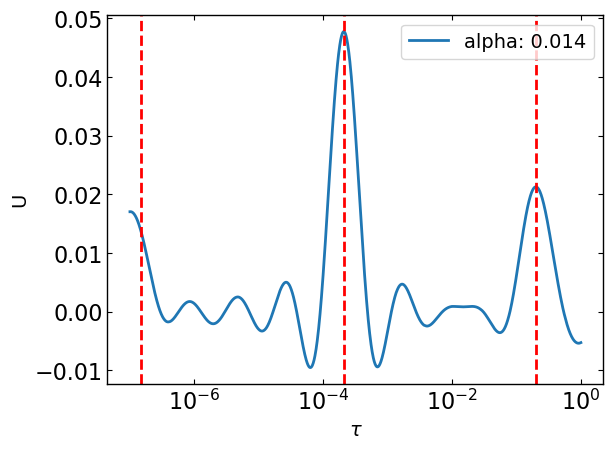

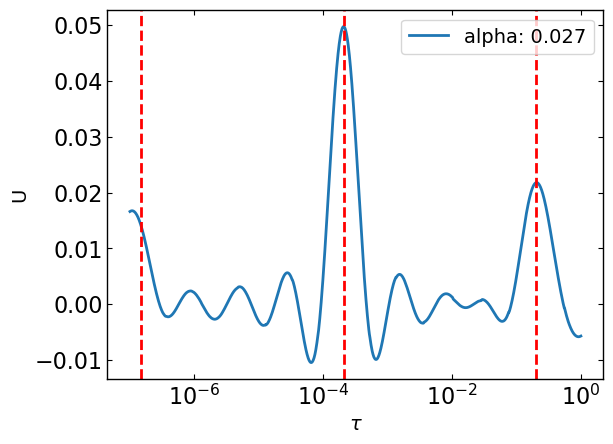

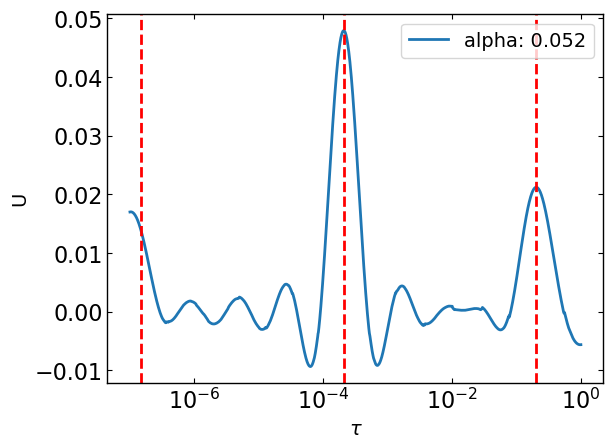

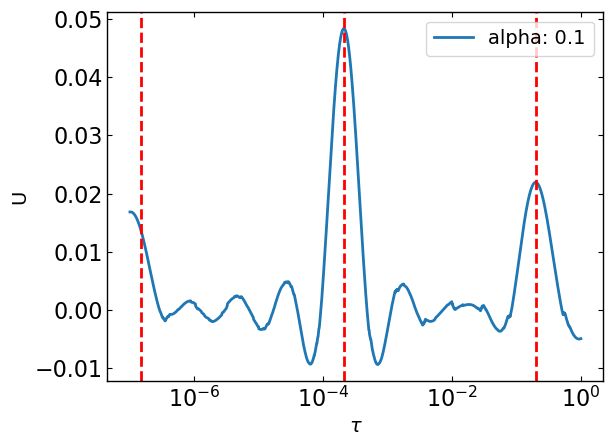

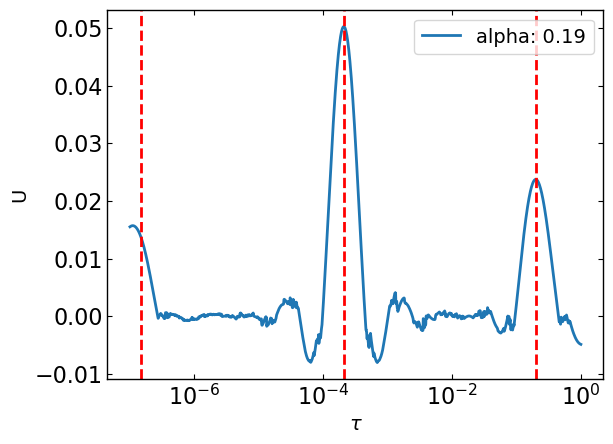

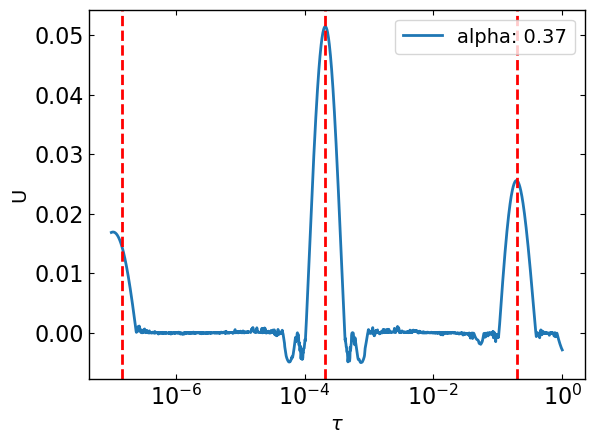

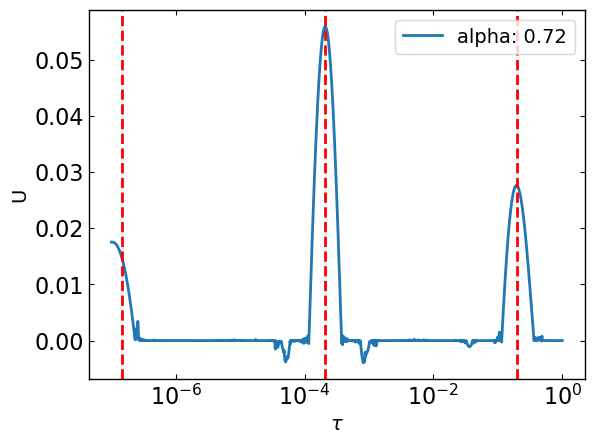

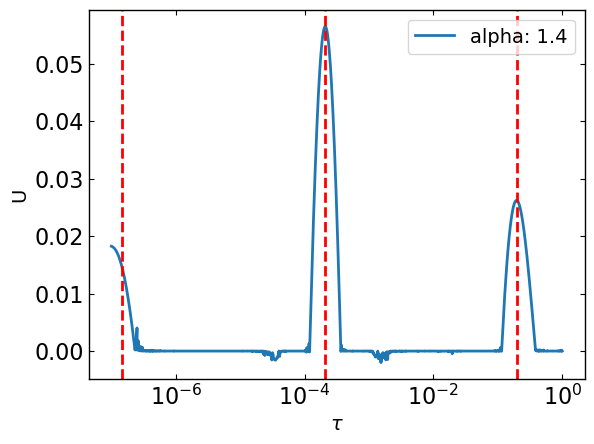

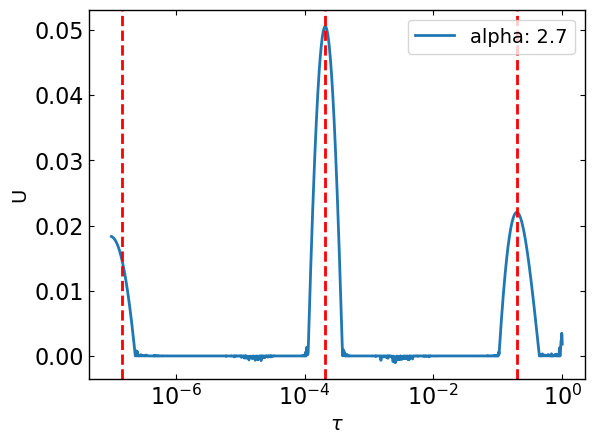

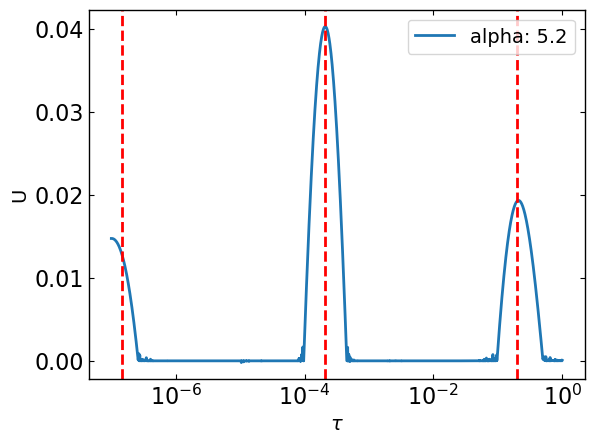

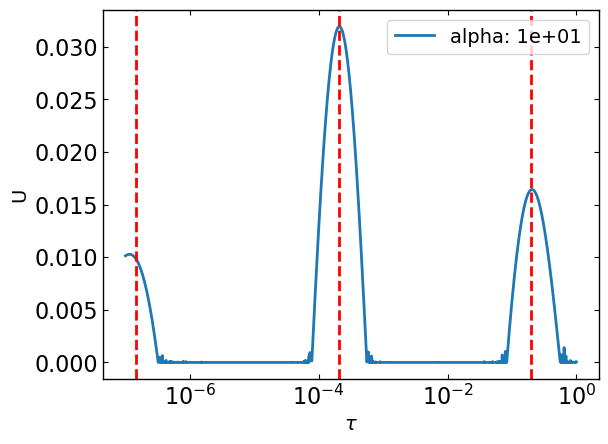

In [10]:
# Plot the resulting DRT curves for each graph
for i in range(len(fits)):
    fit = fits[i]
    plt.plot(fit.tau, fit.U, label=f'alpha: {alpha_values[i]:.2}')
    for tau_value in tau_perf:
        plt.axvline(tau_value, linestyle='--', color='red')
    plt.xlabel("$\\tau$")
    plt.ylabel("U")
    plt.xscale('log')
    plt.legend()
    plt.show()

In [11]:
# Try fitting multiple fits for the same alpha value but with varying numbers of grid points
no_dec = np.log10(time_max/time_min)
m_dec_values = np.geomspace(1, 1000, 20)
fits = []
i=1

for m_dec_value in m_dec_values:
    tau = np.geomspace(time_min, time_max, int(m_dec_value*no_dec))
    fit = drt.fit_DRT_curve_linear_torch(time, y, tau, max_iter=500)
    fits.append(fit)
    print(f"Fit: {i/len(m_dec_values)}")

Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05
Fit: 0.05


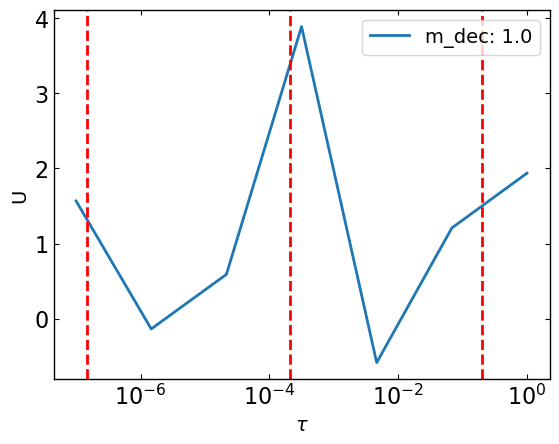

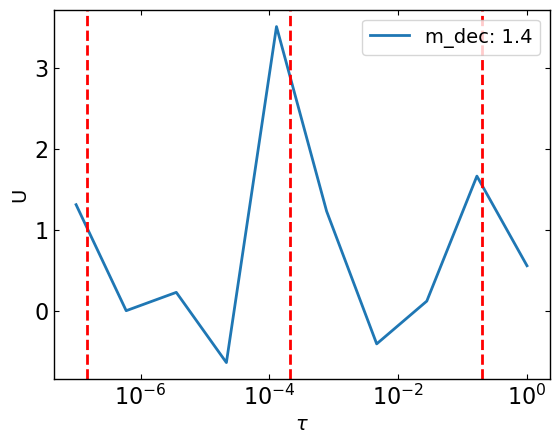

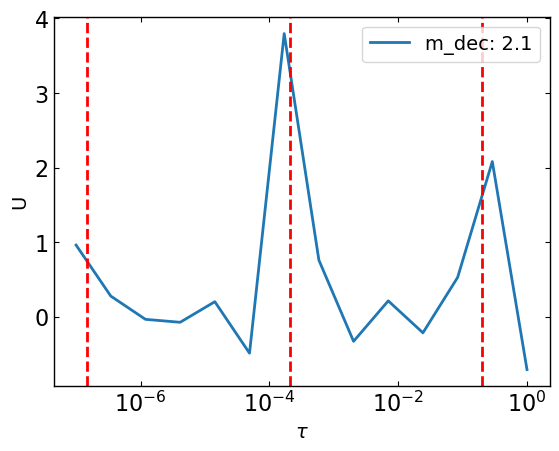

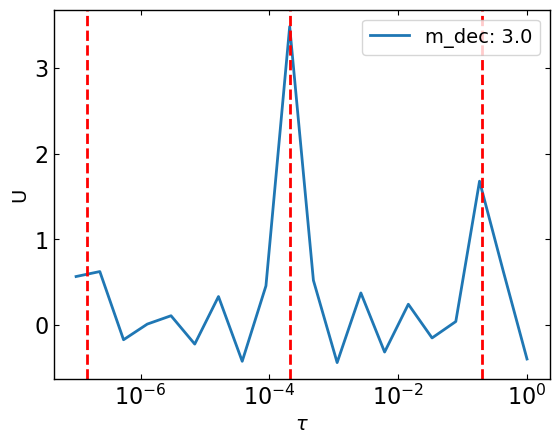

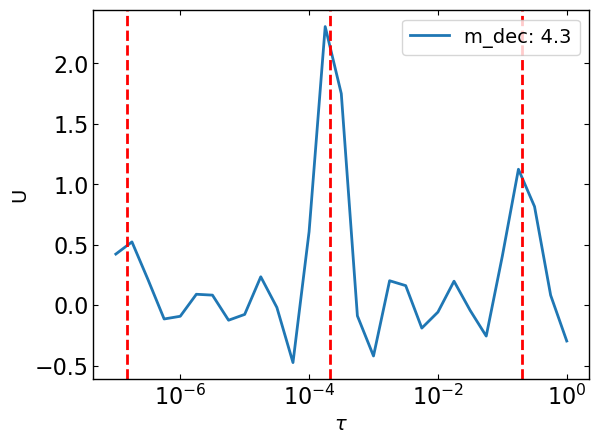

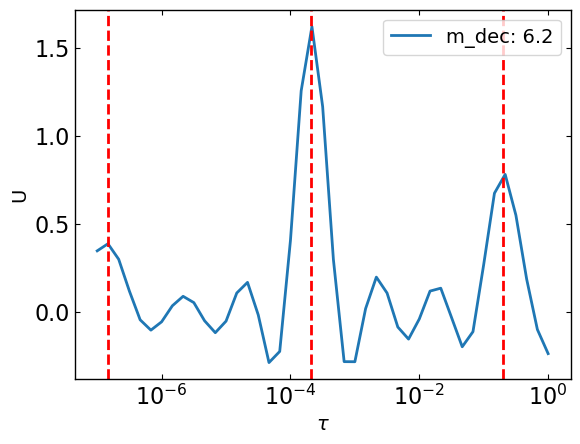

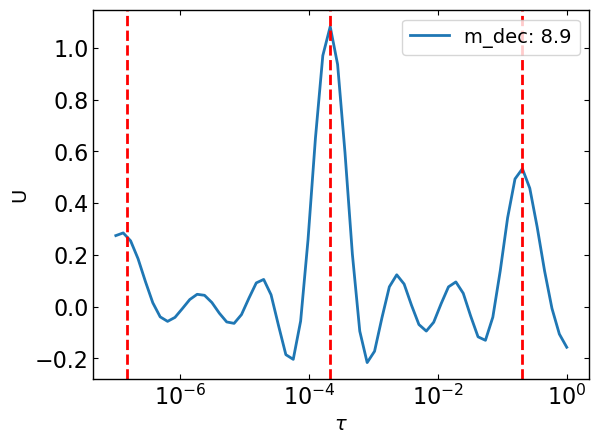

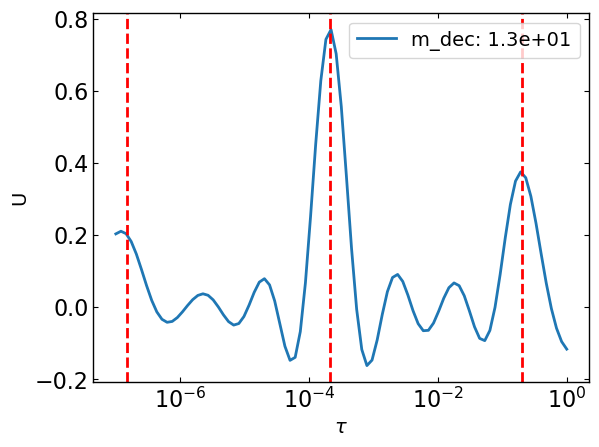

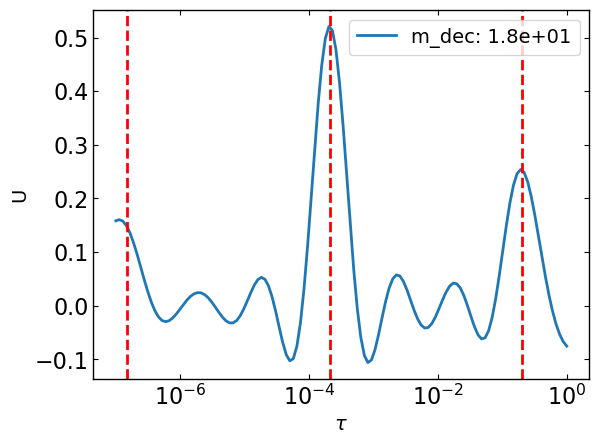

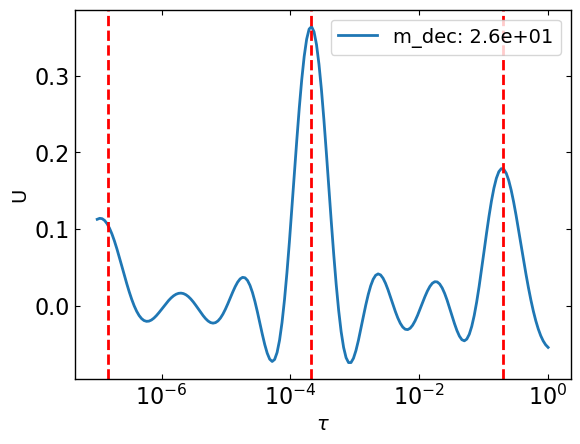

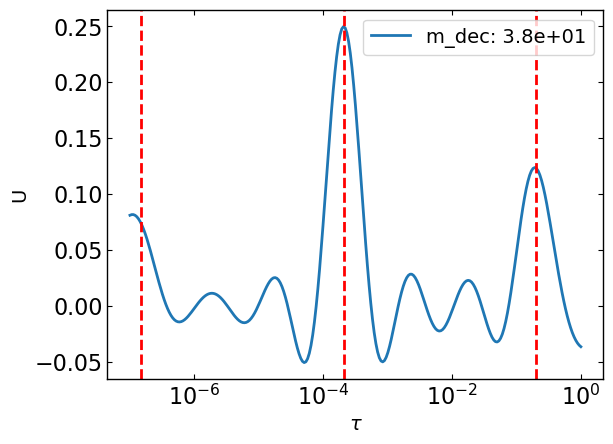

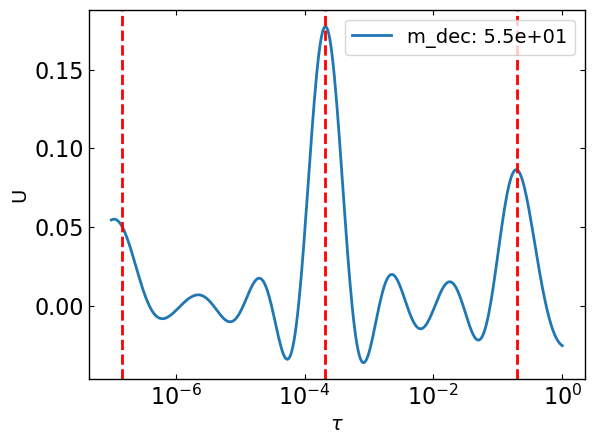

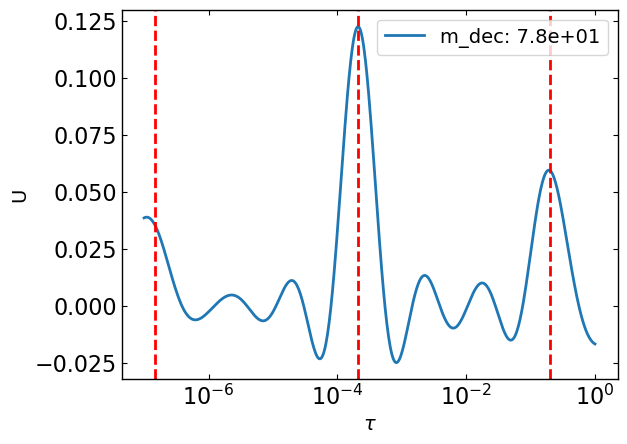

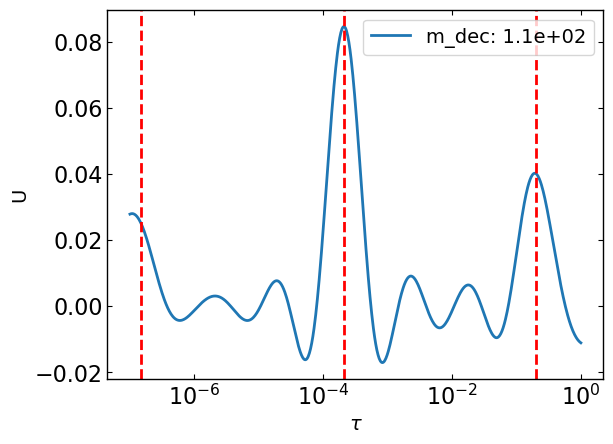

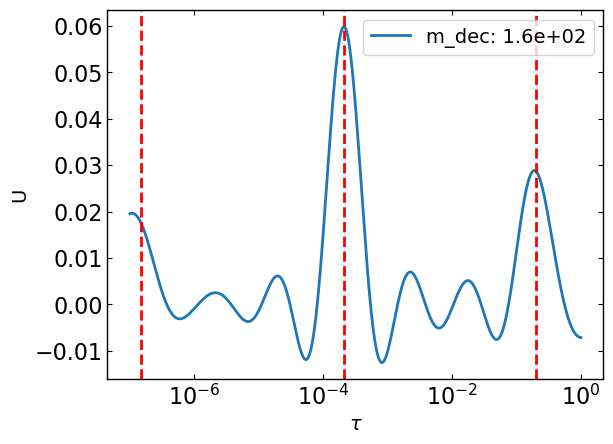

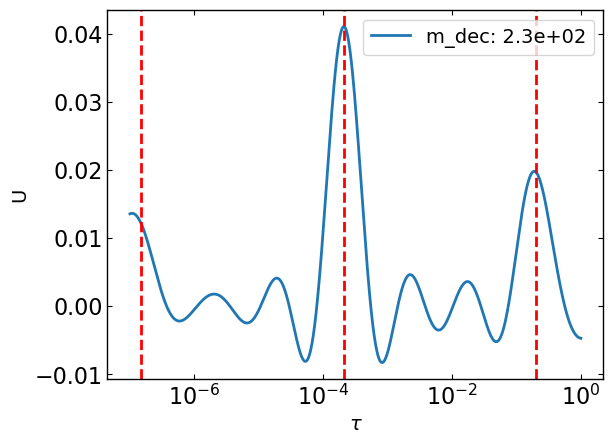

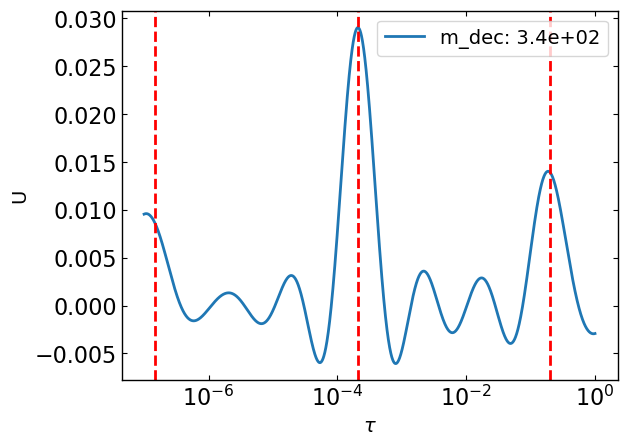

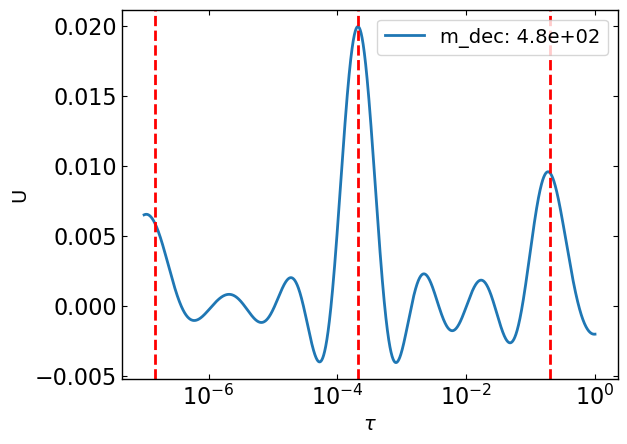

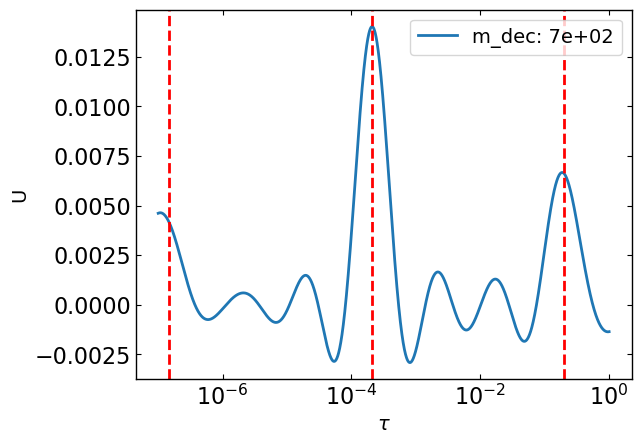

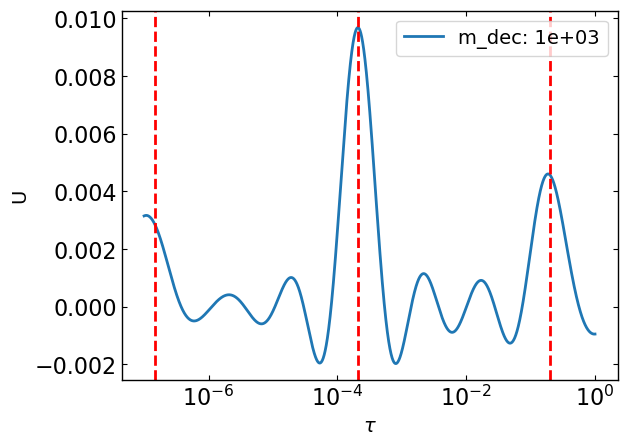

In [12]:
# Plot the resulting DRT curves for each graph
for i in range(len(fits)):
    fit = fits[i]
    plt.plot(fit.tau, fit.U, label=f'm_dec: {m_dec_values[i]:.2}')
    for tau_value in tau_perf:
        plt.axvline(tau_value, linestyle='--', color='red')
    plt.xlabel("$\\tau$")
    plt.ylabel("U")
    plt.xscale('log')
    plt.legend()
    plt.show()

In [19]:
# Try the same thing again but for a higher alpha value
# Try fitting multiple fits for the same alpha value but with varying numbers of grid points
no_dec = np.log10(time_max/time_min)
m_dec_values = np.geomspace(1, 1000, 20)
fits = []

for m_dec_value in m_dec_values:
    tau = np.geomspace(time_min, time_max, int(m_dec_value*no_dec))
    fit = drt.fit_DRT_curve_linear_torch(time, y, tau, max_iter=500, alpha=1)
    fits.append(fit)

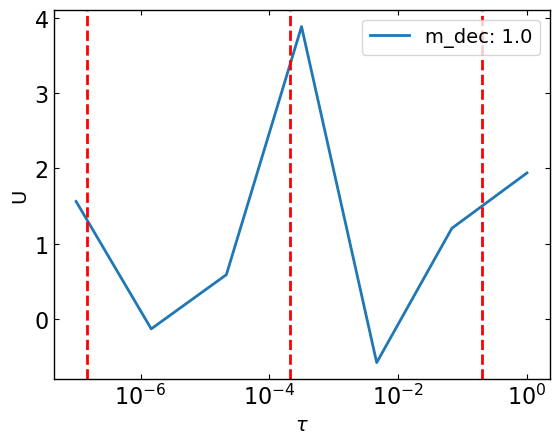

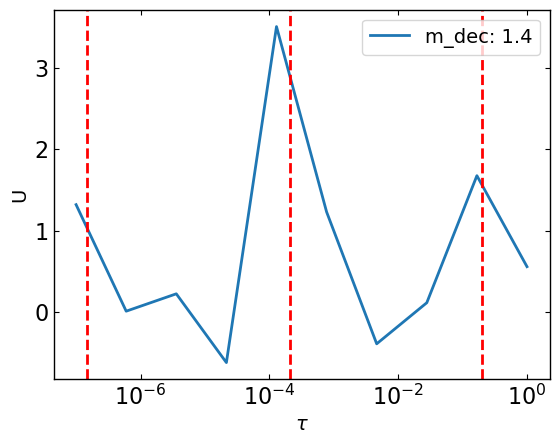

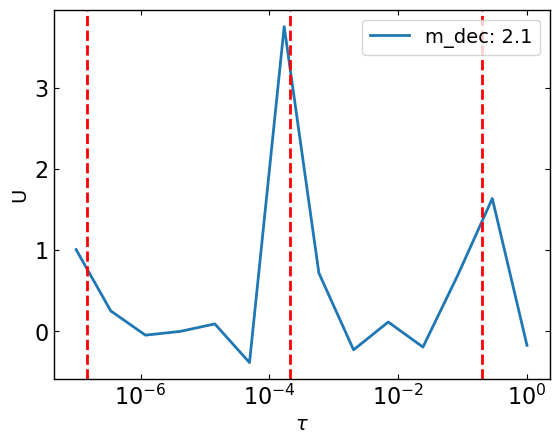

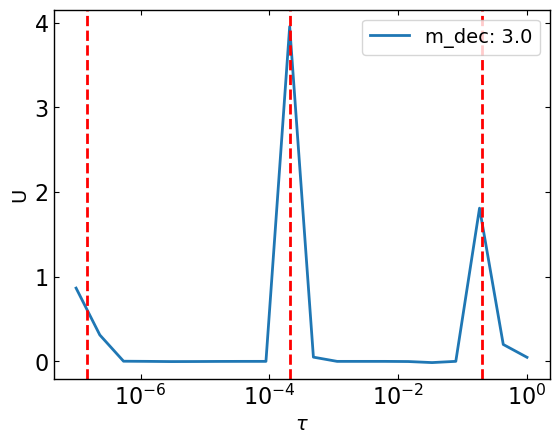

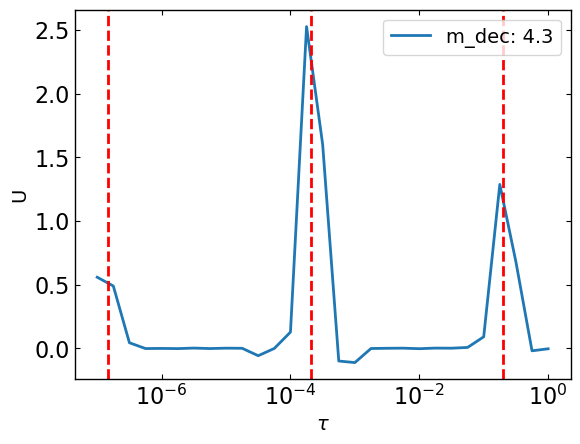

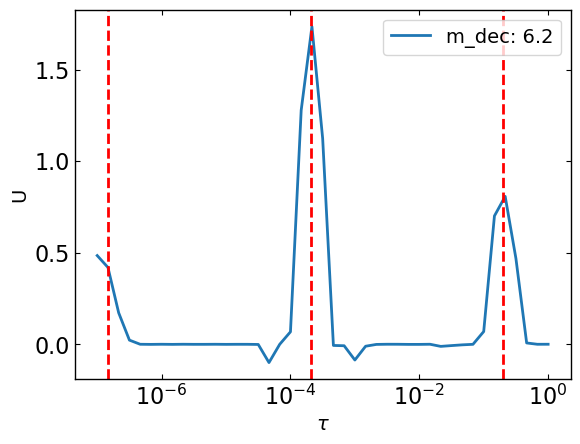

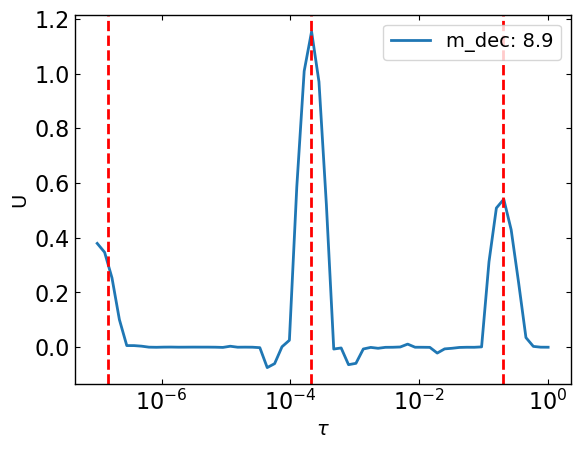

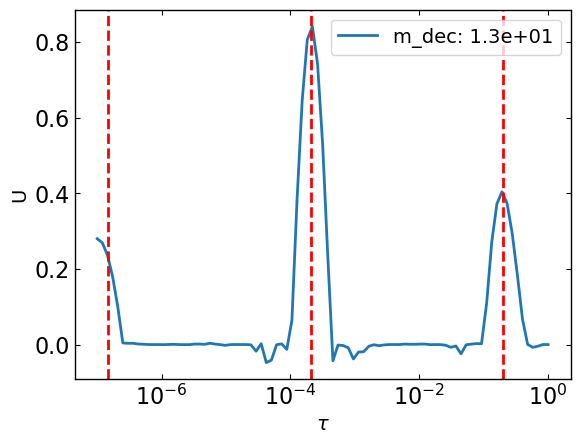

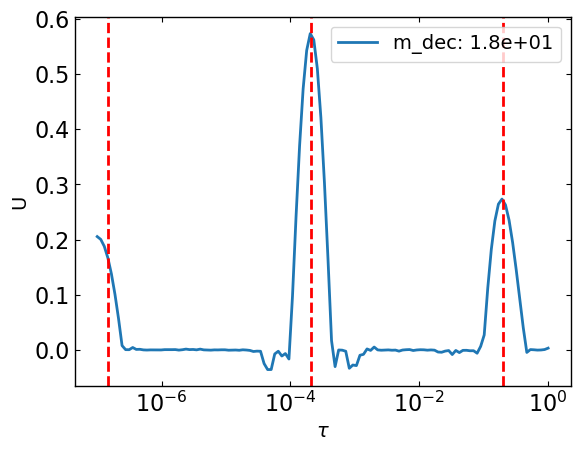

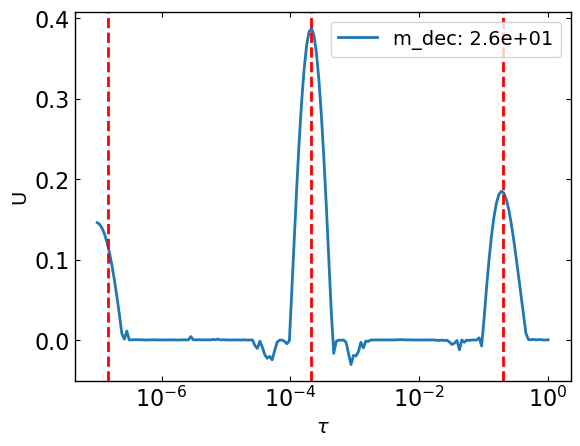

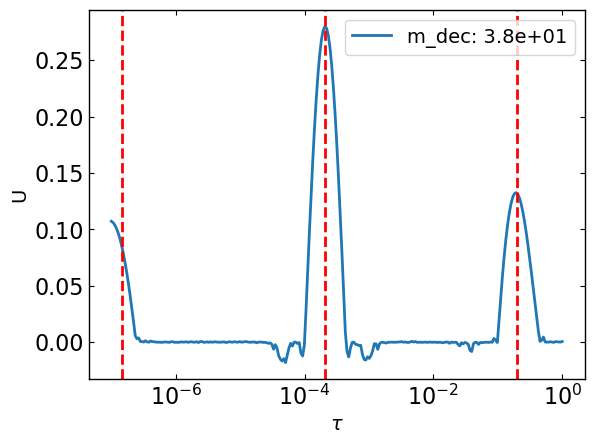

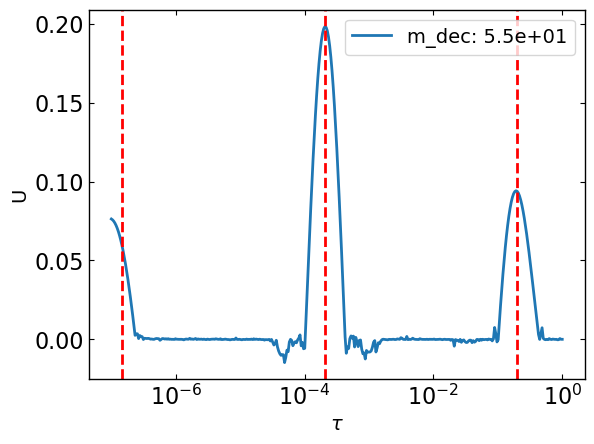

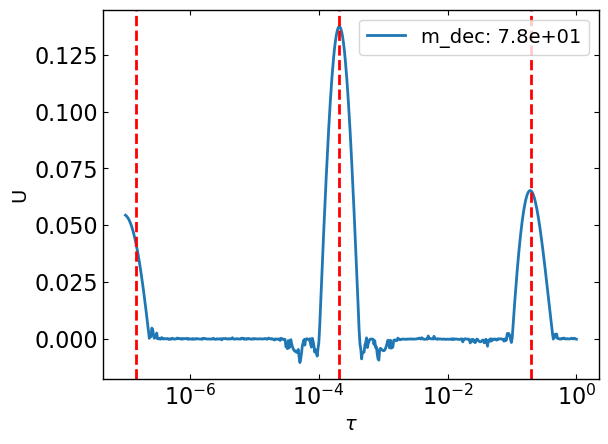

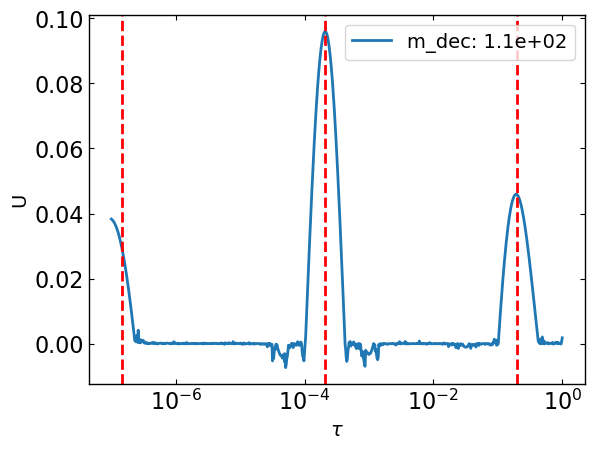

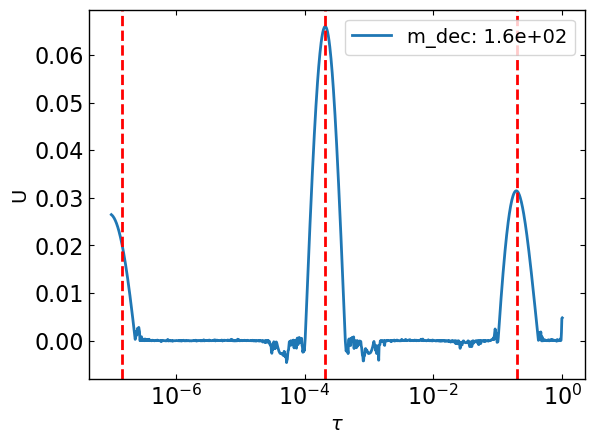

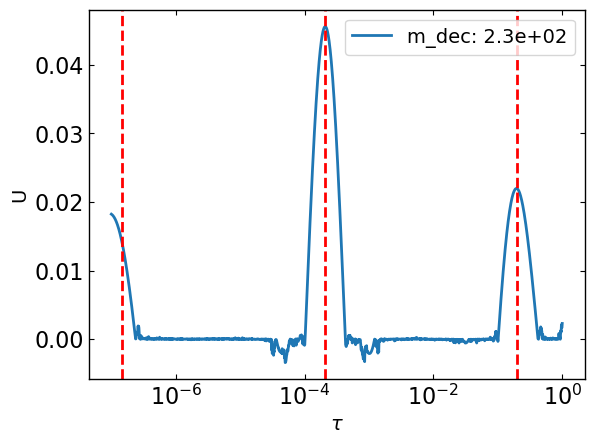

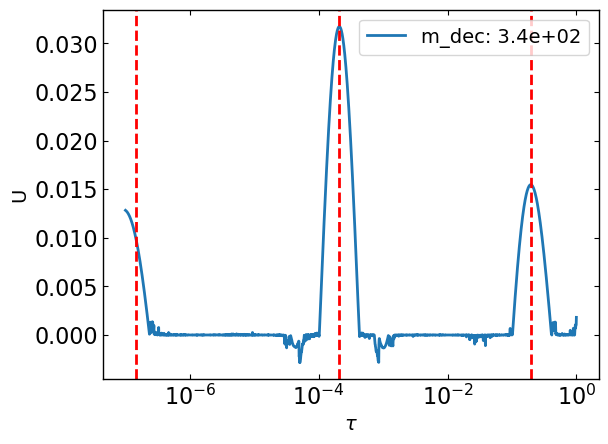

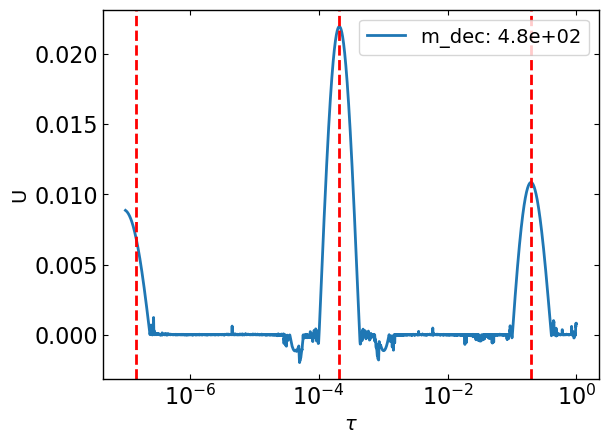

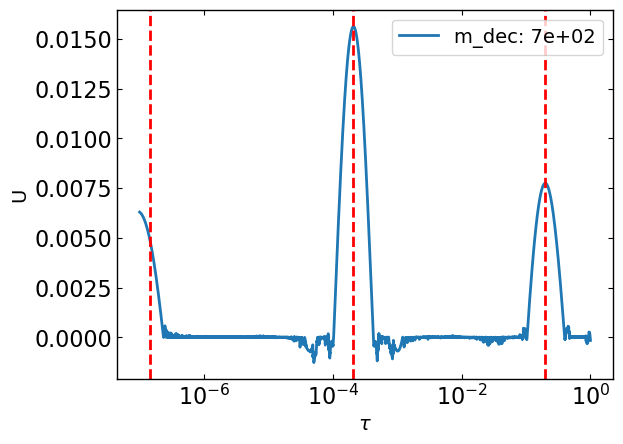

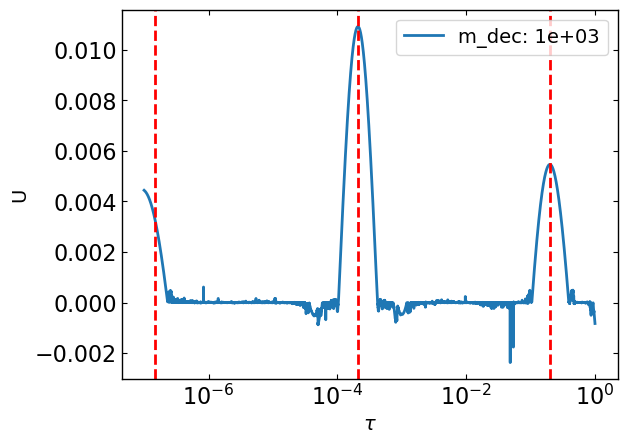

In [20]:
# Plot the resulting DRT curves for each graph
for i in range(len(fits)):
    fit = fits[i]
    plt.plot(fit.tau, fit.U, label=f'm_dec: {m_dec_values[i]:.2}')
    for tau_value in tau_perf:
        plt.axvline(tau_value, linestyle='--', color='red')
    plt.xlabel("$\\tau$")
    plt.ylabel("U")
    plt.xscale('log')
    plt.legend()
    plt.show()